In [1]:
import pika

In [2]:
connection = pika.BlockingConnection(
    pika.ConnectionParameters(host="localhost"),
)

In [3]:
channel = connection.channel()

In [6]:
channel.exchange_declare('RHEED', exchange_type='direct')

<METHOD(['channel_number=1', 'frame_type=1', 'method=<Exchange.DeclareOk>'])>

In [7]:
2e7/1024/1024

19.073486328125

In [8]:
# try to declare special stream queue
# https://www.rabbitmq.com/docs/streams
# channel.queueDeclare(
#   "my-stream",
#   true,         // durable
#   false, false, // not exclusive, not auto-delete
#   Collections.singletonMap("x-queue-type", "stream")
# );

# Map<String, Object> arguments = new HashMap<>();
# arguments.put("x-queue-type", "stream");
# arguments.put("x-max-length-bytes", 20_000_000_000); // maximum stream size: 20 GB
# arguments.put("x-stream-max-segment-size-bytes", 100_000_000); // size of segment files: 100 MB
# channel.queueDeclare(
#   "my-stream",
#   true,         // durable
#   false, false, // not exclusive, not auto-delete
#   arguments
# );

result = channel.queue_declare(
    queue = "RHEED-stream",
    passive = False,
    durable = True,
    exclusive = False,
    auto_delete = False,
    arguments = {
        "x-queue-type": "stream",
        "x-max-length-bytes": int(1e8),
        "x-stream-max-segment-size-bytes": int(1e7),
    },
)

In [9]:
result.method.queue

'RHEED-stream'

In [10]:
channel.queue_bind(
    exchange='RHEED', 
    queue=result.method.queue, 
    routing_key="image"
)

<METHOD(['channel_number=1', 'frame_type=1', 'method=<Queue.BindOk>'])>

In [11]:
import numpy as np

In [12]:
img = np.random.randint(0, 255, size=(540, 720) )

In [89]:
# Importing the PIL library
from PIL import Image
from PIL import ImageDraw
from PIL import ImageFont

In [78]:
import datetime

In [79]:
f"{datetime.datetime.now()}"

'2024-04-12 12:50:43.823176'

In [85]:
img.shape

(540, 720)

In [116]:
datetime.datetime.now().time().isoformat()

'13:02:08.744816'

In [125]:
# Call draw Method to add 2D graphics in an image
pil_img = Image.fromarray(img)
I1 = ImageDraw.Draw( pil_img )
 
# Add Text to an image
I1.text((150, 200), f"{datetime.datetime.now().time().isoformat()}", fill=(0), font=ImageFont.truetype("FreeMono.ttf", size=75))
 

In [126]:
import matplotlib.pyplot as plt

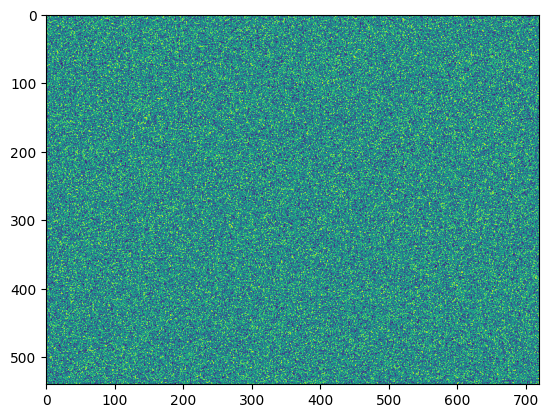

In [127]:
plt.imshow(img)

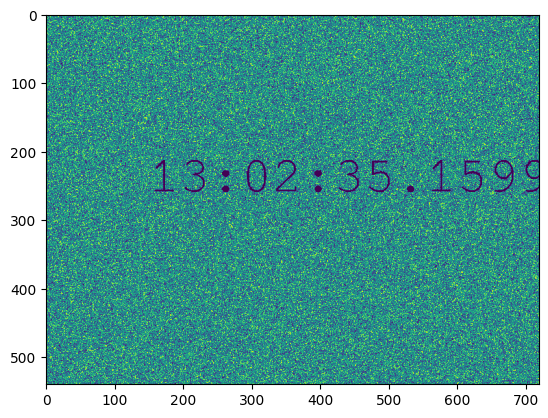

In [128]:
plt.imshow(np.array(pil_img))

In [16]:
img

array([[179, 206, 147, ..., 240, 163,  89],
       [171, 128,  68, ..., 133, 203, 165],
       [ 88,  51, 212, ...,  56,  41,  74],
       ...,
       [104, 189, 180, ..., 231, 149, 191],
       [113, 207, 229, ...,  11, 215, 249],
       [ 75,  85, 164, ...,   8, 198, 130]])

In [21]:
np.unpackbits(img.astype(np.uint8))

array([1, 0, 1, ..., 0, 1, 0], dtype=uint8)

In [28]:
img.dtype

dtype('int64')

In [29]:
dt = np.int16
img = img.astype(dt)
img_bytes = img.tobytes()

In [42]:
h, w = img.shape

In [44]:
import struct

In [62]:
hw_bytes = struct.pack("<HH", h, w)

In [50]:
h_bytes = struct.pack("<H", h)

In [52]:
w_bytes = struct.pack("<H", w)

In [51]:
struct.unpack("<H", h_bytes)

(540,)

In [63]:
struct.unpack("<HH", hw_bytes)

(540, 720)

In [64]:
body = hw_bytes+img_bytes

In [65]:
index = 0
struct.calcsize("<HH")

4

In [68]:
img_shape = struct.unpack("<HH", body[index:index+struct.calcsize("<HH")])

In [70]:
img_flat = np.frombuffer(body[index+struct.calcsize("<HH"):], dtype=dt )

In [72]:
img_bytes[:2]

b'\xb3\x00'

In [73]:
img_flat.shape

(388800,)

In [74]:
img_recover = img_flat.reshape(img_shape)

In [75]:
img_recover == img

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

In [ ]:
dt = np.int16

while True:
    img = np.random.randint(0, 255, size=(540, 720) )
    
    # Call draw Method to add 2D graphics in an image
    pil_img = Image.fromarray(img)
    I1 = ImageDraw.Draw( pil_img )
     
    # Add Text to an image
    I1.text((150, 200), f"{datetime.datetime.now().time().isoformat()}", fill=(0), font=ImageFont.truetype("FreeMono.ttf", size=75))

    img = np.array(pil_img)
    
    img = img.astype(dt)
    img_bytes = img.tobytes()
    
    h, w = img.shape
    hw_bytes = struct.pack("<HH", h, w)
    body = hw_bytes+img_bytes
    
    channel.basic_publish(
        exchange='RHEED',
        routing_key="image",
        body = body
    )